## Loading intro stuff

In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/constants.py"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [3]:
# VLA k band 9 mm (ish)
bands = ["Band 4 nterms2", "Band 5", "Band 6", "Band 7 nterms2"]
bands_naming = ['Band4_nterms2', 'Band5', 'Band6', 'Band7_nterms2']

band_colors = [alma_band_colors[b] for b in bands]
ms = [alma_band_ms[b] for b in bands]

In [4]:
df_POLF = load_POLF(bands)

In [5]:
df_POLF

,Band,POLF_Gaussian,POLF_maxPOLI,POLF_maxStokesI,POLF_mean
0,Band 4 nterms2,1.187728,1.561384,1.367706,1.372273
1,Band 5,0.914925,1.030456,0.972170,0.972517
2,Band 6,1.445312,1.486287,1.463922,1.465174
3,Band 7 nterms2,0.830213,1.084152,1.042140,0.985502


In [6]:
f_values = [1, 0.3, 0.1, 0.01]

## Load Files

In [7]:
csv_files = {
    1:   "P_omega_vs_amax_f_1_CustomBounds.csv",
    0.3: "P_omega_vs_amax_f_0_3_CustomBounds.csv",
    0.1: "P_omega_vs_amax_f_0_1_CustomBounds.csv",
    0.01:"P_omega_vs_amax_f_0_01_CustomBounds.csv"
}

In [14]:
find_best_sf

<function POLF_Functions.find_best_sf(a_max_f_dist_micron, P_times_omega, df_POLF, print_results=False)>

In [13]:
# Storage dicts
a_max_f_dist_micron = {}
P_times_omega = {}
best_a_max_f = {}
best_POLF = {}
best_sf = {}

# Loop through each f value
for f, fname in csv_files.items():
    df = pd.read_csv(P_omega_data_folder_path + fname)

    # x-axis (grain sizes in micron)
    a_max_f_dist_micron[f] = df["a_max_f_micron"].values

    # y-values (P*omega for each band)
    P_times_omega[f] = np.column_stack([df[f"P_times_omega_{b}"].values for b in bands_naming])

    # run best_sf calculation per f
    best_a_max_f[f], best_POLF[f], best_sf[f] = find_best_sf(
        a_max_f_dist_micron[f], P_times_omega[f], df_POLF, print_results=False
    )

## Plot one of the figures

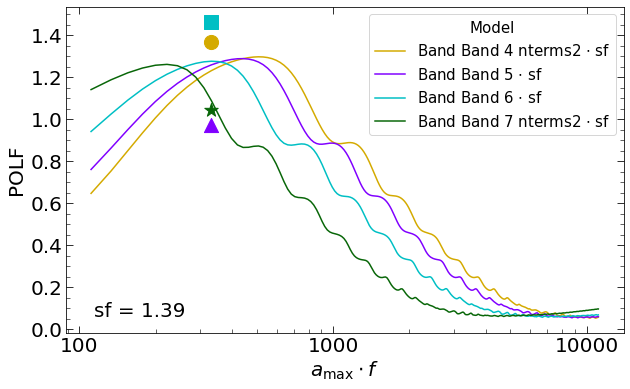

In [10]:
f_plot = 0.3

fig, ax = plot_a_vs_POLF(a_max_f_dist_micron[f_plot], 
                         P_times_omega[f_plot], 
                         best_sf[f_plot], 
                         bands, 
                         y_plot = 'af', legend = 'w sf')

ax.text(0.05, 0.05, f'sf = {best_sf[f_plot]:.2f}', transform=ax.transAxes, fontsize = 20)


for i in range(len(bands)):
    ax.scatter(best_a_max_f[f_plot], best_POLF[f_plot][i], c = band_colors[i], marker = ms[i], s = 200)

add an upper limit of 3 sigma with VLA non-detection

## Plot all

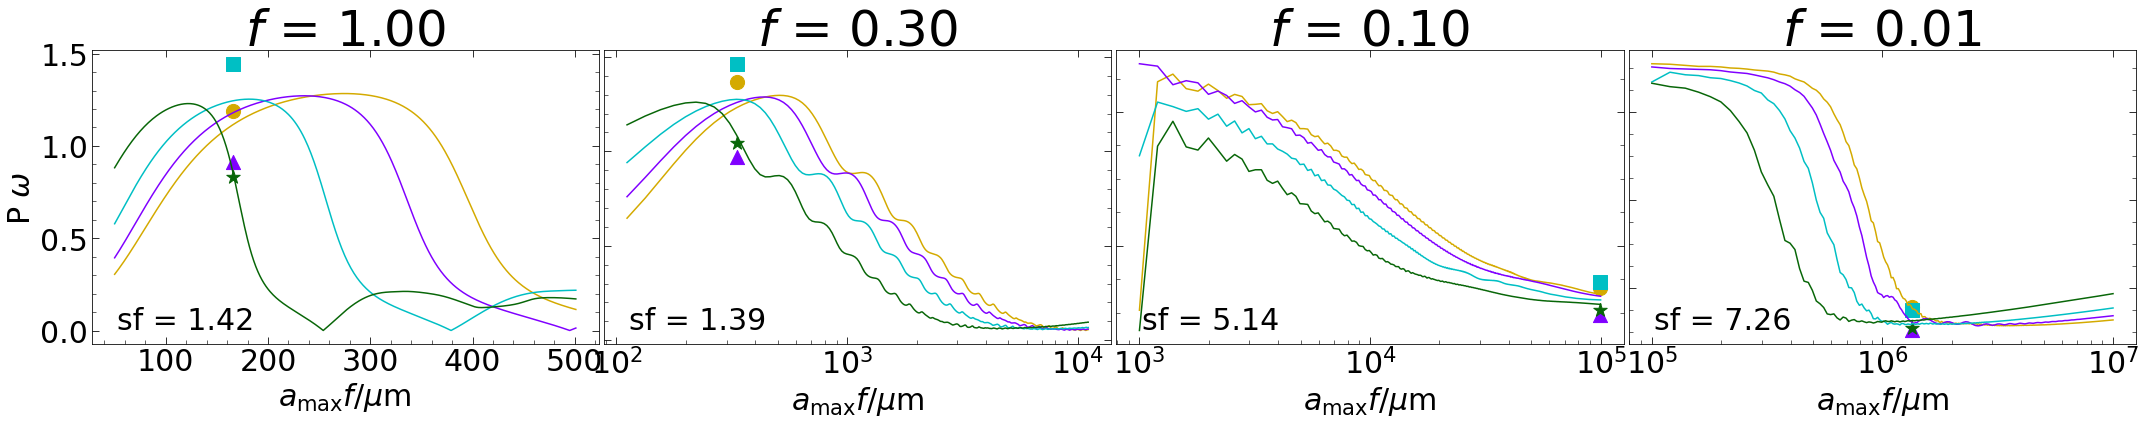

In [11]:
log_f = [0.3, 0.1, 0.01]

sf = 1.5

fig, ax = plt.subplots(1, 4, figsize=(30, 6))

for i, f in enumerate(f_values):  # loop over subplots + f keys
    if i == 0:
        ax[i].set_ylabel('P $\omega$', fontsize=axis_label_fs*sf)
    else:
        ax[i].set_yticklabels([])
        ax[i].set_ylabel('')
        ax[i].tick_params(left=False)
        
    if f in log_f:
        ax[i].set_xscale("log")


    # x-axis label
    ax[i].set_xlabel(r'$a_{\mathrm{max}} f / \mu\mathrm{m}$', fontsize=axis_label_fs*sf)

    # ticks
    ax[i].minorticks_on()
    ax[i].tick_params(axis="x", which="minor", direction="in", left=True, right=True, length=4)
    ax[i].tick_params(axis="y", which="minor", direction="in", left=True, right=True, length=4)
    ax[i].tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs*sf)
    ax[i].tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs*sf)

    ax[i].set_title(f'$f$ = {f:.2f}', fontsize=50)
    
    ax[i].text(0.05, 0.05, f'sf = {best_sf[f]:.2f}', transform=ax[i].transAxes, fontsize = 30)

    # plot each band for this f
    for j, b in enumerate(bands):
        ax[i].scatter(best_a_max_f[f], best_POLF[f][j],
                      c=band_colors[j], marker=ms[j], s=200)

        ax[i].plot(a_max_f_dist_micron[f],
                   P_times_omega[f][:, j] * best_sf[f],
                   color=band_colors[j], ls='-',
                   label=f'Band {b}')

plt.tight_layout()
plt.subplots_adjust(wspace=0.01, hspace=0)
plt.show()

In [12]:
best_POLF

{1: 0    1.187728
 1    0.914925
 2    1.445312
 3    0.830213
 Name: POLF_Gaussian, dtype: float64,
 0.3: 0    1.367706
 1    0.972170
 2    1.463922
 3    1.042140
 Name: POLF_maxStokesI, dtype: float64,
 0.1: 0    1.367706
 1    0.972170
 2    1.463922
 3    1.042140
 Name: POLF_maxStokesI, dtype: float64,
 0.01: 0    1.561384
 1    1.030456
 2    1.486287
 3    1.084152
 Name: POLF_maxPOLI, dtype: float64}